### Task IX: Kolmogorov-Arnold Network
Implement a classical Kolmogorov-Arnold Network using basis-splines or some other KAN architecture and apply it to MNIST. Show its performance on the test data. Comment on potential ideas to extend this classical KAN architecture to a quantum KAN and sketch out the architecture in detail.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Step 1: Data Preparation and Normalization
The first step involves setting up the data pipeline using torchvision. A Compose transform is applied, that first converts the raw MNIST images into PyTorch tensors and then applies a normalization transformation. Specifically, the mean $\mu = 0.1307$ and standard deviation $\sigma = 0.3081$ are used, which are the global statistics for the MNIST dataset. This centers the input data around zero, which is crucial for the KAN because our B-spline knots are positioned in a fixed range [-1, +1]. Then the datasets are wrapped in DataLoader objects to handle batching and shuffling, ensuring the model sees a stochastic variety of digits during training.

In [2]:
# Load raw data as tensors
dataset = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
loader = torch.utils.data.DataLoader(dataset, batch_size=60000)

data = next(iter(loader))[0]

# Calculate mean and std
print(f"Mean: {data.mean().item()}") # Should be ~0.1307
print(f"Std: {data.std().item()}")   # Should be ~0.3081

Mean: 0.13066047430038452
Std: 0.30810782313346863


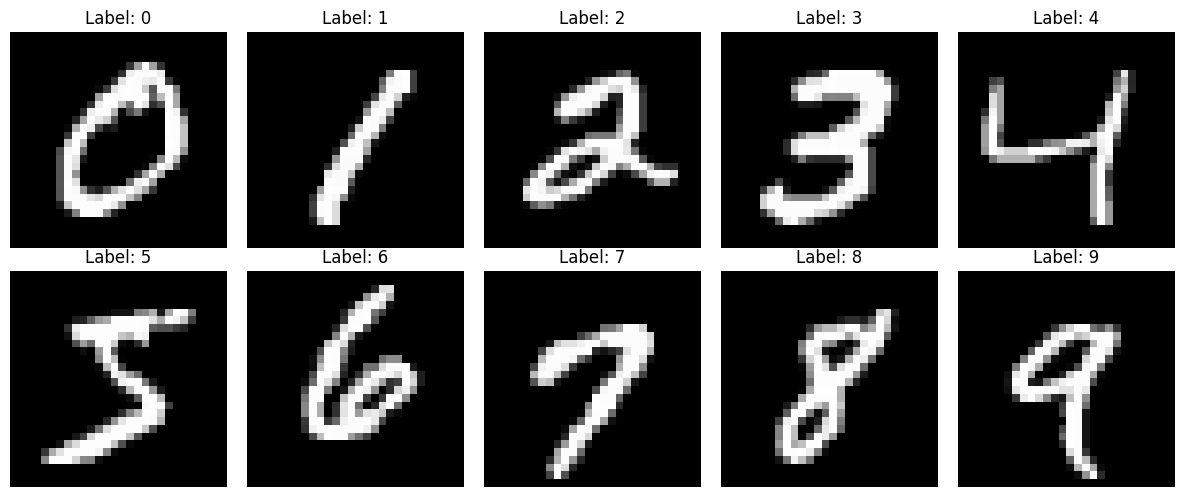

In [3]:
# Dictionary to store the first image found for each label
found_images = {}
for image, label in dataset:
    if label not in found_images:
        found_images[label] = image
    if len(found_images) == 10:
        break

# Plotting in a 2x5 grid
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # MNIST images are [1, 28, 28], we squeeze to [28, 28] for grayscale plotting
    plt.imshow(found_images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# --- Step 1: Dataset (Standard MNIST) ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True
)
test_loader = DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=1000, shuffle=False
)

### Step 2: The KAN Layer Architecture
The core of the Kolmogorov-Arnold Network is the KANLayer, which replaces the fixed activation functions of a standard MLP with learnable univariate functions on each edge. In this implementation, each edge $(i, j)$ represents a function $\phi_{i,j}(x) = b(x) + s(x)$. The $b(x)$ term is a "base" linear transformation followed by a SiLU (Swish) activation, defined as $\text{SiLU}(x) = x \cdot \sigma(x)$. This provides a stable, smooth gradient during the early stages of training. The $s(x)$ term is the spline component, which allows the network to learn complex, non-linear shapes that a standard ReLU cannot capture.


To make the spline learnable, a set of basis functions (knots) are distributed across the input space. A linear B-spline (or "hat function") is implemented where the basis for a knot $k$ is calculated as $B(x) = \max(0, 1 - |x - k|)$. This creates a local activation that only fires when the input $x$ is near a specific knot. To efficiently map the input features to output features, Einstein Summation (einsum) is used. The operation bik,oik->bo performs a weighted sum of these basis activations across all input dimensions and knots to produce the final output features, effectively learning a unique curve for every single connection in the layer.

In [5]:
# --- Step 2: Authentic KAN Layer ---
class KANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_knots=5, spline_order=3):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_knots = num_knots

        # 1. Residual base weights (Linear path with SiLU)
        # This acts as a regular MLP backbone to help the spline converge.
        self.base_weight = nn.Parameter(torch.randn(out_features, in_features) * 0.1)

        # 2. Spline weights (The "Learnable Activation" path)
        # Shape: (out, in, knots)
        self.spline_weight = nn.Parameter(torch.randn(out_features, in_features, num_knots) * 0.1)

        # 3. Fixed Grid/Knots (Uniformly spaced in [-1, 1])
        self.register_buffer("knots", torch.linspace(-1, 1, num_knots))

    def forward(self, x):
        # x shape: [batch, in_features]

        # --- Base Path (Residual) ---
        # Standard linear transform followed by SiLU (Swish)
        base_output = F.linear(F.silu(x), self.base_weight)

        # --- Spline Path ---
        # Expand x to calculate distance to knots: [batch, in, 1] - [knots] -> [batch, in, knots]
        # We use a simple linear B-spline (hat function) for efficiency
        x_unsqueezed = x.unsqueeze(-1)
        basis = torch.clamp(1 - torch.abs(x_unsqueezed - self.knots), min=0)

        # Einstein sum: Apply learnable weights to the spline basis
        # 'bik,oik->bo' means:
        # b: batch, i: in_features, k: knots, o: out_features
        spline_output = torch.einsum('bik,oik->bo', basis, self.spline_weight)

        return base_output + spline_output

### Step 3: Model Composition

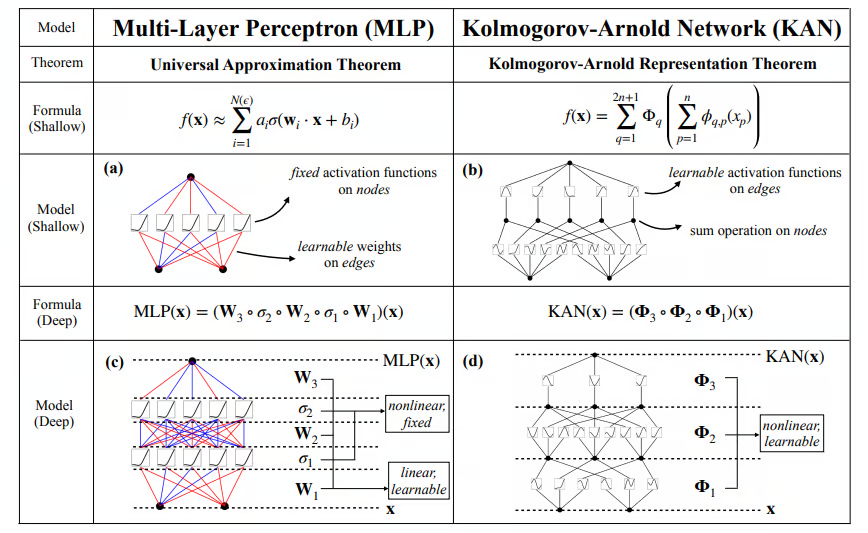

Image source: https://arxiv.org/pdf/2404.19756

The KAN class defines the global architecture by stacking two KANLayer instances. Unlike a traditional Multi-Layer Perceptron (MLP) where you must sandwich a nn.ReLU() between layers, a KAN does not require external activation functions. The non-linearity is "built-in" to the layers themselves. The first layer transforms the flattened 784-pixel input into a 64-dimensional latent space, and the second layer reduces this to the 10-class output. Mathematically, the model represents the function:$$f(x) = \sum_{j} \Phi_{L,j} \circ \dots \circ \sum_{i} \Phi_{1,i}(x_i)$$where each $\Phi$ is the learnable spline function defined in the previous steps.

In [6]:
# --- Step 3: KAN Model Architecture ---
class KAN(nn.Module):
    def __init__(self):
        super().__init__()
        # KANs usually need fewer neurons than MLPs for the same task
        self.layer1 = KANLayer(784, 64)
        self.layer2 = KANLayer(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten: [Batch, 784]
        x = self.layer1(x)
        # Note: No ReLU here! The non-linearity is inside KANLayer.
        x = self.layer2(x)
        return x

### Step 4: Optimization and Training Logic
For training, the AdamW optimizer is utilized, which incorporates decoupled weight decay to regularize the spline coefficients and prevent overfitting. The loss function is CrossEntropyLoss, suitable for multi-class classification. During the forward pass, the model calculates the logits for each digit (0-9). The gradients are backpropagated not just to a weight matrix, but specifically to the spline_weight parameters that control the shape of the activation functions. This allows the network to "wiggle" its internal functions to better fit the distribution of the handwritten digits.

In [7]:
# --- Step 4: Training Setup and loop ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KAN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

print(f"Training on {device}...")

# --- Training Loop ---
losses = []
for epoch in range(20):
    model.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)

    print(f"Epoch {epoch+1} | Avg Loss: {total_loss/len(train_loader):.4f}")

Training on cpu...
Epoch 1 | Avg Loss: 0.4577
Epoch 2 | Avg Loss: 0.2402
Epoch 3 | Avg Loss: 0.1899
Epoch 4 | Avg Loss: 0.1642
Epoch 5 | Avg Loss: 0.1395
Epoch 6 | Avg Loss: 0.1238
Epoch 7 | Avg Loss: 0.1102
Epoch 8 | Avg Loss: 0.0999
Epoch 9 | Avg Loss: 0.0924
Epoch 10 | Avg Loss: 0.0826
Epoch 11 | Avg Loss: 0.0776
Epoch 12 | Avg Loss: 0.0693
Epoch 13 | Avg Loss: 0.0636
Epoch 14 | Avg Loss: 0.0607
Epoch 15 | Avg Loss: 0.0547
Epoch 16 | Avg Loss: 0.0519
Epoch 17 | Avg Loss: 0.0477
Epoch 18 | Avg Loss: 0.0415
Epoch 19 | Avg Loss: 0.0432
Epoch 20 | Avg Loss: 0.0437


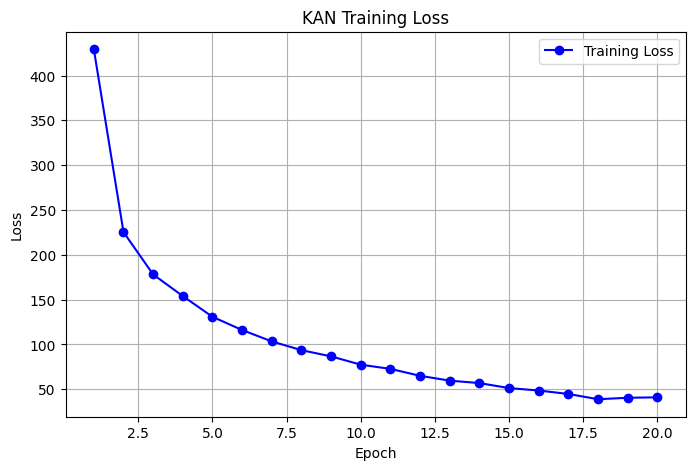

In [8]:
# Plotting the loss stored during training
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', color='b', label='Training Loss')
plt.title('KAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

### Step 5: Evaluation and Accuracy Metrics
The final step switches the model to eval() mode, which disables dropout (if present) and ensures consistent behavior. The testing loop is wrapped in a torch.no_grad() context to save memory and computation by skipping gradient calculations. The model's performance is measured by comparing the argmax of the output logits—representing the most likely digit—against the ground-truth labels. The resulting accuracy provides a clear metric of how well the KAN has generalized its learned spline functions to unseen data compared to the training set.

In [9]:
# --- Step 5: Evaluation ---
model.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"\nFinal Test Accuracy: {100. * correct / len(test_loader.dataset):.2f}%")


Final Test Accuracy: 96.00%
